# Latent Potential Demand Estimation

In this notebook, we walk through the methodology of estimating the latent maximum monthly volume potential for the month of January 2026. Since we do not have a true 'target variable' (ground truth), we approach this as a **left-censored demand problem**.

## Methodology
1. **Load Gold Features**: We use the pre-aggregated `model_input.parquet` which contains our POI data, historical transactions, and censoring flags.
2. **Censoring Detection**: We identify outlets that hit a 'plateau' (very low variance, capped deliveries) or had high stockout/return ratios.
3. **Peer Group Quantile Uplift**: For constrained outlets, we override their historical volume with the **90th percentile** of their peer group (same Size, Type, and Distributor).

In [5]:
# Run this cell to ensure all required packages are installed in this specific kernel
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn fastparquet pyarrow --quiet
print('Dependencies installed successfully!')



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Dependencies installed successfully!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# Load the Gold data
df = pd.read_parquet('../data/gold/model_input.parquet')
print(f'Loaded {len(df)} outlets for modeling.')
df.head()

Loaded 20000 outlets for modeling.


,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,Outlet_Size_Score,Type_Bakery,Type_Eatery,Type_Grocery,Type_Hotel,Type_Kiosk,...,poi_banks_count_1km,poi_supermarkets_count_1km,poi_fuel_stations_count_1km,Distributor_ID,Jan_Seasonality_Score,Peer_Group_90th_Vol,Is_Plateaued,Is_Underperforming_Peer,is_high_return_censored,is_stockout_censored
0,OUT_00001,Medium,1,Grocery,2,0,0,1,0,0,...,0,1,1,DIST_W_03,0.0,371.819041,0,0,0,0
1,OUT_00002,Small,0,Hotel,1,0,0,0,1,0,...,0,0,0,DIST_W_02,0.0,144.689433,0,0,0,0
2,OUT_00003,Small,1,Pharmacy,1,0,0,0,0,0,...,0,0,0,DIST_W_02,0.0,154.613646,0,0,0,0
3,OUT_00004,Medium,2,Pharmacy,2,0,0,0,0,0,...,0,0,0,DIST_W_01,0.0,374.218881,0,0,0,0
4,OUT_00005,Medium,2,Kiosk,2,0,0,0,0,1,...,0,0,0,DIST_W_03,0.0,345.226381,0,0,0,0


## 1. Visualizing the Censoring Problem
Outlets with extremely low Coefficient of Variation (CV) are suspicious. In the FMCG sector, perfectly flat sales indicate an artificial cap (like a rigid credit limit or strict delivery allocation), not true demand.

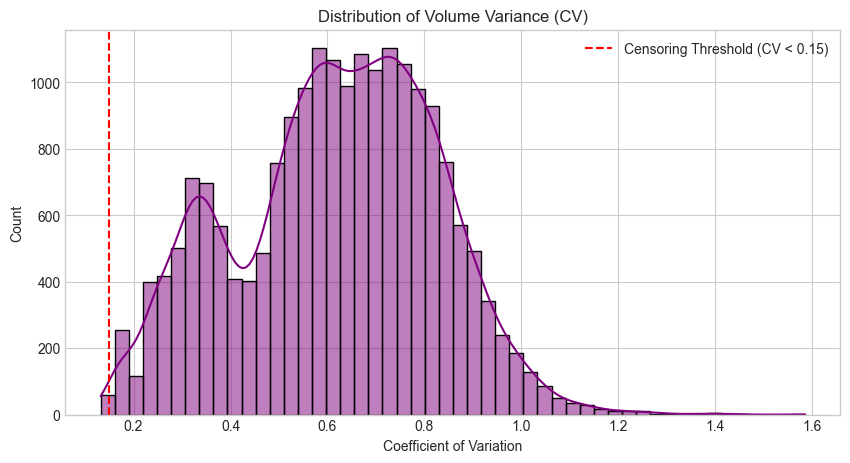

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['cv_volume'], bins=50, kde=True, color='purple')
plt.axvline(0.15, color='red', linestyle='--', label='Censoring Threshold (CV < 0.15)')
plt.title('Distribution of Volume Variance (CV)')
plt.xlabel('Coefficient of Variation')
plt.legend()
plt.show()

## 2. Peer Group Analysis
To estimate what a constrained outlet *could* have sold, we group them by similar characteristics: `Type`, `Size`, and `Distributor`.

In [8]:
peer_groups = df.groupby(['Outlet_Size_Score', 'Distributor_ID'])['peak_volume'].agg(['mean', 'median', lambda x: np.percentile(x, 90)])
peer_groups.rename(columns={'<lambda_0>': '90th_Percentile'}, inplace=True)
peer_groups.head(10)

mean      median  90th_Percentile
Outlet_Size_Score Distributor_ID                                         
0                 DIST_C_01       119.832041  119.051609       142.568877
                  DIST_C_02       117.809560  115.335744       136.043870
                  DIST_C_03       122.033285  119.530213       141.842357
                  DIST_NW_01      118.646041  113.638049       149.319892
                  DIST_NW_02      106.496639   96.167759       141.718281
                  DIST_S_01       121.137104  123.252070       151.286728
                  DIST_S_02       115.957312  121.897959       135.935784
                  DIST_W_01       112.220501  110.166982       135.500164
                  DIST_W_02       144.146368  107.761714       161.865696
                  DIST_W_03       223.901460  111.919654       559.522330

## 3. Estimating Latent Potential
We calculate the estimated potential as follows:
- **Unconstrained (Normal):** Base estimate = Recent 3-month average + Seasonality impact.
- **Constrained (Censored):** Potential = Max(Base, Peak Volume, Peer Group 90th Percentile).

In [9]:
# Base Estimate (Recent 3m avg adjusted for January seasonality)
seas_adj = 1.0 + (df['Jan_Seasonality_Score'].fillna(0) * 0.1)
base_est = df['recent_3m_avg'] * seas_adj

# Peer Group 90th Percentile Ceiling
peer_est = df['Peer_Group_90th_Vol'].fillna(base_est)
peak_est = df['peak_volume'].fillna(base_est)

# Censoring Condition
is_censored = (df['Is_Plateaued'] == 1) | (df['is_stockout_censored'] == 1) | (df['is_high_return_censored'] == 1)

df['Latent_Potential'] = np.where(
    is_censored,
    np.maximum.reduce([base_est * 1.1, peer_est, peak_est * 1.05]),
    np.maximum.reduce([base_est, peak_est * 0.9])
)

# Global Market Growth Factor for 2026
df['Latent_Potential'] = df['Latent_Potential'] * 1.05

print(f"Average Latent Potential: {df['Latent_Potential'].mean():.2f} L")
print(f"Average Historical Peak: {df['peak_volume'].mean():.2f} L")

Average Latent Potential: 375.17 L
Average Historical Peak: 395.98 L


### Distribution Shift (Observed vs Potential)
Notice how the Latent Potential distribution shifts slightly to the right, reflecting the uncapping of constrained demand.

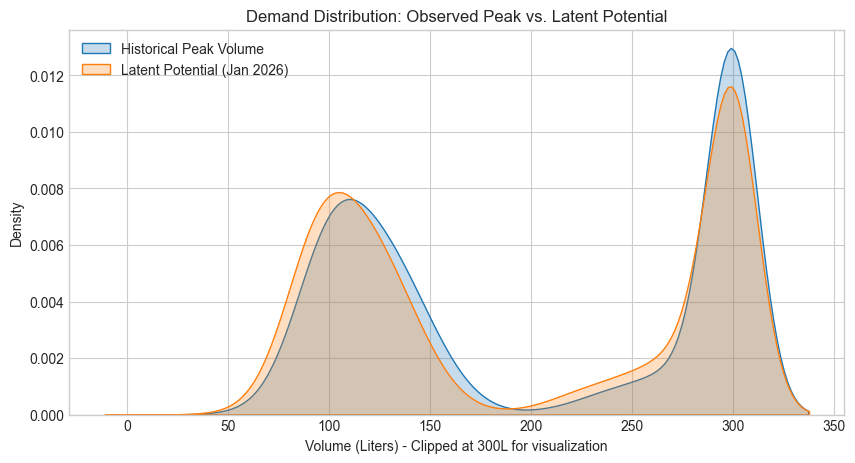

In [10]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df['peak_volume'].clip(upper=300), label='Historical Peak Volume', fill=True)
sns.kdeplot(df['Latent_Potential'].clip(upper=300), label='Latent Potential (Jan 2026)', fill=True)
plt.title('Demand Distribution: Observed Peak vs. Latent Potential')
plt.xlabel('Volume (Liters) - Clipped at 300L for visualization')
plt.legend()
plt.show()

In [11]:
# Prepare final output
output = df[['Outlet_ID', 'Latent_Potential']].copy()
output['Latent_Potential'] = output['Latent_Potential'].round(2)
output.to_csv('../output/insightai_predictions.csv', index=False)
print("Saved final predictions to output/insightai_predictions.csv")

Saved final predictions to output/insightai_predictions.csv
